In [1]:
#Importation of all the necessary packages
import os
import numpy as np
from matplotlib import pylab as plt
import bempp_cl.api as bempp            
import gmsh
from IPython import get_ipython
import matplotlib
from bempp_cl.core import opencl_kernels
import bempp_cl.api as bempp

opencl_kernels.show_available_platforms_and_devices()
opencl_kernels.set_default_cpu_device(1,0)

0: AMD Accelerated Parallel Processing
    0: gfx90c
1: Intel(R) OpenCL
    0: AMD Ryzen 5 5500U with Radeon Graphics         


In [3]:
#bibliothèque si on utilise les fichiers npz
import os
import numpy as np
from matplotlib import pylab as plt           
from IPython import get_ipython
import matplotlib

In [4]:
#Function used to empty the RAM
os.environ['PYOPENCL_COMPILER_OUTPUT']='1'

#Pour redémarrer le kernel
#Ctrl + Shift + P
#Jupyter: Restart Kernel

In [6]:
#Definition of classes to describe the geometry
class Cylinder:
    def __init__(self, length, radius, coord_x, coord_y, coord_z):
        self.length = length
        self.radius = radius
        self.coord_x = coord_x
        self.coord_y = coord_y
        self.coord_z = coord_z


    def ajouter(self):
        cyl_tag = gmsh.model.occ.addCylinder(self.coord_x, self.coord_y, self.coord_z, 0, 0, self.length, self.radius)
        cyl_surf = gmsh.model.occ.get_surface_loops(cyl_tag)[1][0]
        cyl_curv_tag = gmsh.model.geo.add_surface_loop(cyl_surf)

        return cyl_tag, cyl_surf, cyl_curv_tag



class Aperture: 
    def __init__(self, radius_ext, radius_in, thickness, coord_x, coord_y, coord_z):
        self.radius_ext = radius_ext
        self.radius_in = radius_in
        self.thickness = thickness
        self.coord_x = coord_x
        self.coord_y = coord_y
        self.coord_z = coord_z


    def ajouter (self):
        aperture_out = gmsh.model.occ.addCylinder(self.coord_x, self.coord_y, self.coord_z, 0, 0, self.thickness, self.radius_ext)
        aperture_in = gmsh.model.occ.addCylinder(self.coord_x, self.coord_y, self.coord_z, 0, 0, self.thickness, self.radius_in)
        apert_vol , _=  gmsh.model.occ.cut([(3,aperture_out)],[(3,aperture_in)])
        apert_tag=apert_vol[0][1]
        apert_surf = gmsh.model.occ.get_surface_loops(apert_tag)[1][0]

        return apert_tag, apert_surf



class Shield:
    def __init__(self, length, radius_ext, radius_in, radius_hole, thickness, coord_x, coord_y, coord_z):
        self.length = length
        self.radius_ext = radius_ext
        self.radius_in = radius_in
        self.radius_hole = radius_hole
        self.thickness = thickness
        self.coord_x = coord_x
        self.coord_y = coord_y
        self.coord_z = coord_z


    def ajouter(self):
        shield_in = gmsh.model.occ.addCylinder(self.coord_x, self.coord_y, self.coord_z + self.thickness, 0, 0, self.length -2*self.thickness, self.radius_in)
        shield_out = gmsh.model.occ.addCylinder(self.coord_x, self.coord_y, self.coord_z, 0, 0, self.length, self.radius_ext)
        shield , _=  gmsh.model.occ.cut([(3,shield_out)],[(3,shield_in)])
        shield_hole1 = gmsh.model.occ.addCylinder(self.coord_x, self.coord_y, self.length - self.thickness, 0, 0, self.thickness, self.radius_hole)
        shield_hole2 = gmsh.model.occ.addCylinder(self.coord_x, self.coord_y, self.coord_z, 0, 0, self.thickness, self.radius_hole)
        shield_vol_1, _=  gmsh.model.occ.cut([(3,shield[0][1])],[(3,shield_hole1)])
        shield_vol_2, _=  gmsh.model.occ.cut([(3,shield_vol_1[0][1])],[(3,shield_hole2)])
        shield_tag=shield_vol_2[0][1]
        shield_surf = gmsh.model.occ.get_surface_loops(shield_tag)[1][0]

        return shield_tag, shield_surf
    


class Dimensions: 
    def __init__(self, 
                dist_shield_apert, dist_apert_quad,
                radius_ext_shield, radius_in_shield, thickness_shield, 
                radius_apert, thickness_apert, 
                length_cylinder, 
                radius_axis):
        self.dist_shield_apert = dist_shield_apert
        self.dist_apert_quad = dist_apert_quad

        self.radius_ext_shield = radius_ext_shield
        self.radius_in_shield = radius_in_shield
        self.thickness_shield = thickness_shield

        self.radius_apert = radius_apert
        self.thickness_apert = thickness_apert

        self.length_cylinder = length_cylinder

        self.radius_axis = radius_axis
            
            
    def total_length(self):
        return 2*self.dist_shield_apert + 2*self.thickness_shield + 2*self.dist_apert_quad + 2*self.thickness_apert + self.length_cylinder
    

    def coord_cylinder(self):
        x_or_y = 2*self.radius_axis
        z = self.thickness_shield + self.dist_shield_apert + self.thickness_apert + self.dist_apert_quad

        return x_or_y, z
    

    def coord_apert(self):
        z1 = self.thickness_shield + self.dist_shield_apert
        z2 = self.thickness_shield + self.dist_shield_apert + self.thickness_apert + 2*self.dist_apert_quad + self.length_cylinder

        return z1, z2

    def coord_tot(self):
        start_shield1 = 0
        end_shield1 = start_shield1 + self.thickness_shield

        start_apert1 = end_shield1 + self.dist_shield_apert
        end_apert1 = start_apert1 + self.thickness_apert

        start_cyl = end_apert1 + self.dist_apert_quad
        end_cyl = start_cyl + self.length_cylinder

        start_apert2 = end_cyl + self.dist_apert_quad
        end_apert2 = start_apert2 + self.thickness_apert

        start_shield2 = end_apert2 + self.dist_shield_apert
        end_shield2 = start_shield2 + self.thickness_shield

        return start_shield1, end_shield1, start_apert1, start_apert2, start_cyl, end_cyl, start_apert2, end_apert2, start_shield2, end_shield2
    

In [7]:
#Definition of the geometry 

#Settings of the dimensions of the geometry 
dimensions = Dimensions(4, 4, 21, 19, 2, 15, 2, 14, 3.49)
''' 
#1 - Distance between the sield ant the aperture 
#2 - Distance between the aperture and the cylinders (d in Okayama's paper)
#3 - Exterior radius of the shield 
#4 - Inside radius of the shield 
#5 - Thickness of the shield
#6 - Radius of the aperture 
#7 - Thickness of the aperture 
#8 - Length of the cylinder (l in Okayama's paper)
#9 - Radius of the elements around the axis (a in Okayama's paper)
'''

def generate_mesh(): 

    gmsh.initialize()
    gmsh.clear()
    gmsh.model.add("Quadrupole lens")

    cylinder1 = Cylinder(dimensions.length_cylinder, dimensions.radius_axis, dimensions.coord_cylinder()[0], 0, dimensions.coord_cylinder()[1])
    cylinder1 = Cylinder.ajouter(cylinder1)

    cylinder2 = Cylinder(dimensions.length_cylinder, dimensions.radius_axis, -dimensions.coord_cylinder()[0], 0, dimensions.coord_cylinder()[1])
    cylinder2 = Cylinder.ajouter(cylinder2)

    cylinder3 = Cylinder(dimensions.length_cylinder, dimensions.radius_axis, 0, dimensions.coord_cylinder()[0], dimensions.coord_cylinder()[1])
    cylinder3 = Cylinder.ajouter(cylinder3)

    cylinder4 = Cylinder(dimensions.length_cylinder, dimensions.radius_axis, 0, -dimensions.coord_cylinder()[0], dimensions.coord_cylinder()[1])
    cylinder4 = Cylinder.ajouter(cylinder4)


    aperture1 = Aperture(dimensions.radius_apert, dimensions.radius_axis, dimensions.thickness_apert, 0, 0, dimensions.coord_apert()[0])
    aperture1 = Aperture.ajouter(aperture1)

    aperture2 = Aperture(dimensions.radius_apert, dimensions.radius_axis, dimensions.thickness_apert, 0, 0, dimensions.coord_apert()[1])
    aperture2 = Aperture.ajouter(aperture2)


    shield = Shield(dimensions.total_length(), dimensions.radius_ext_shield, dimensions.radius_in_shield, dimensions.radius_axis, dimensions.thickness_shield, 0, 0, 0)
    shield = Shield.ajouter(shield)
    print("#############")
    print(gmsh.model.geo.add_curve_loops(cylinder1[2]))

    #Creation of the mesh
    gmsh.model.occ.synchronize()

    #Outwards orientation of the surfaces' normals
    gmsh.model.mesh.setOutwardOrientation(aperture1[0])
    gmsh.model.mesh.setOutwardOrientation(aperture2[0])
    gmsh.model.mesh.setOutwardOrientation(cylinder1[0])
    gmsh.model.mesh.setOutwardOrientation(cylinder2[0])
    gmsh.model.mesh.setOutwardOrientation(cylinder3[0])
    gmsh.model.mesh.setOutwardOrientation(cylinder4[0])
    gmsh.model.mesh.setOutwardOrientation(shield[0])

    #Adds surfaces on top of the volumes created 
    group_id_apert1 = gmsh.model.addPhysicalGroup(2,aperture1[1])
    group_id_apert2 = gmsh.model.addPhysicalGroup(2,aperture2[1])
    group_id_cyl1 = gmsh.model.addPhysicalGroup(2,cylinder1[1])
    group_id_cyl2 = gmsh.model.addPhysicalGroup(2,cylinder2[1])
    group_id_cyl3 = gmsh.model.addPhysicalGroup(2,cylinder3[1])
    group_id_cyl4 = gmsh.model.addPhysicalGroup(2,cylinder4[1])
    group_id_shield = gmsh.model.addPhysicalGroup(2,shield[1])

    #Size of the mesh
    #ATTENTION, MeshSizeMin and MeshSizeMax need to be equal
    gmsh.option.set_number('Mesh.MeshSizeMin', 1.3)
    gmsh.option.set_number('Mesh.MeshSizeMax', 1.3)
    gmsh.option.set_number("Mesh.MeshSizeFactor", 1.3)
    gmsh.option.set_number('Mesh.MeshSizeFromCurvature', 12)

    gmsh.model.mesh.generate(2)

    #Creates a file .msh
    gmsh.write("mesh_quadrupole.msh")

    #Opens a terminal to see the geometry (il faut préalablement installer une extension dans Visual studio code intitulé "STL Viewer")
    gmsh.fltk.run()

    gmsh.finalize()

    return group_id_apert1, group_id_apert2, group_id_cyl1, group_id_cyl2, group_id_cyl3, group_id_cyl4, group_id_shield

In [8]:
#values of the voltage we use

class Potentials:
    def __init__(self, pot_electrode, pot_apert1, pot_apert2, pot_shield, pot_acceleration):
        self.pot_electrode = pot_electrode #quadrupole 
        self.pot_apert1 = pot_apert1 #first aperture (pour le champs rond)
        self.pot_apert2 = pot_apert2 #second aperture 
        self.pot_shield = pot_shield #shield (0)
        self.pot_acceleration = pot_acceleration #ion acceleration potential

In [9]:
#Potential extraction

#Settings of the potentials

#On prend Vq2 sur le papier d'okayama
Va=20000
Vq2=-0.0299087*Va
Vapert1=-0.18808*Va
Vapert2=0.10918*Va

potentials = Potentials(Vq2, Vapert1, Vapert2, 0, Va)


def calculate_field(elec_id):
    plt.clf()

    #Importation of the mesh
    grid= bempp.import_grid("mesh_quadrupole.msh")

    ##Definition of different spaces
    dp0_space = bempp.function_space(grid, "DP", 0)
    p1_space = bempp.function_space(grid, "P", 1)

    #Definition of different operators (single layer, double layer and identity)
    identity = bempp.operators.boundary.sparse.identity(p1_space, p1_space, dp0_space)
    dlp = bempp.operators.boundary.laplace.double_layer(p1_space, p1_space, dp0_space)
    slp = bempp.operators.boundary.laplace.single_layer(dp0_space, p1_space, dp0_space)

    #Settings of the potentials
    pot_apert1 = potentials.pot_apert1
    pot_apert2 = potentials.pot_apert2
    pot_electrode = potentials.pot_electrode
    pot_shield = potentials.pot_shield

    @bempp.real_callable
    #Setting of the potential on the different elements of the geometry
    def dirichlet_data(x, n, domain_index, result):
        if domain_index == elec_id[0]: #potential of the 1st aperture
            result[0]=pot_apert1
            
        elif domain_index == elec_id[1]: #potential of the 2nd aperture
            result[0]=pot_apert2
        
        elif domain_index == elec_id[2]: #potential of the 1st electrode
            result[0]=pot_electrode

        elif domain_index == elec_id[3]: #potential of the 2nd electrode
            result[0]=pot_electrode

        elif domain_index == elec_id[4]: #potential of the 3rd electrode
            result[0]=-pot_electrode

        elif domain_index == elec_id[5]: #potential of the 4th electrode
            result[0]=-pot_electrode

        elif domain_index == elec_id[6]: #potential of the shield
            result[0]=pot_shield

    dirichlet_fun = bempp.GridFunction(p1_space, fun=dirichlet_data) 
    
    #bempp.PLOT_BACKEND = "paraview"
    #Prints the potential associated to the geometry 
    #dirichlet_fun.plot() 

    #Sum of the right part of the integral 
    rhs = (-0.5 * identity + dlp) * dirichlet_fun

    #Resolution of the linear system
    neumann_fun, _ = bempp.linalg.cg(slp, rhs, tol=1e-8) #1e-5 à tester

    #Creation of the tracing of the solution
    n_grid_points = 100
    points = np.stack((np.zeros(n_grid_points), np.zeros(n_grid_points), (np.linspace(0, dimensions.total_length(), n_grid_points)))) #x=y=0 and z changes from 0 to elec_id[7][11]=total_length

    #Green's representation
    slp_pot = bempp.operators.potential.laplace.single_layer(dp0_space, points) #total matrix
    u_evaluated = -slp_pot * neumann_fun 

    #Field 
    E = slp_pot = bempp.operators.potential.laplace.single_layer_gradient(dp0_space, points, device_interface="opencl")
    E_eval = -E * neumann_fun

    #Field's 2nd derivative
    D2 = bempp.operators.potential.laplace.single_layer_2nd_deriv(dp0_space,points, device_interface="opencl")
    D2_eval = D2 * neumann_fun
  
    #Field's 3rd derivative
    D3 = bempp.operators.potential.laplace.single_layer_3rd_deriv(dp0_space, points, device_interface="opencl")
    D3_eval = D3 * neumann_fun

    #Field's 4th derivative
    D4 = bempp.operators.potential.laplace.single_layer_4th_deriv(dp0_space, points, device_interface="opencl")
    D4_eval = D4 * neumann_fun

    try:
        from IPython import get_ipython
        ipython = get_ipython()
        if ipython is not None:
            ipython.run_line_magic("matplotlib", "inline")
            ipython = True

    except NameError:
        ipython = False

    #Printing of the solution --> printing of the potential along the z axis ~ 0V
    plt.plot(points[2], u_evaluated[0])
    plt.title("Potentiel du quadrupole d'Okayama le long de l'axe Z")
    plt.xlabel("Position en z (mm)")
    plt.ylabel("Potentiel (V)")
    plt.show()

    savefile="potentiel_quadrupole_VF"
    
    #Creation of a .npz file with the extracted potential
    if "savefile" is not None:
        np.savez_compressed(
    savefile,
    points=points,
    potential=u_evaluated,
    group_id_ap1=elec_id[0],
    group_id_ap2=elec_id[1],
    group_id_cyl1=elec_id[2],
    group_id_cyl2=elec_id[3],
    group_id_cyl3=elec_id[4],
    group_id_cyl4=elec_id[5],
    group_id_shield=elec_id[6],
    dimensions=np.array((dimensions.dist_shield_apert, dimensions.dist_apert_quad, dimensions.radius_ext_shield, dimensions.radius_in_shield, dimensions.thickness_shield,
    dimensions.radius_apert, dimensions.thickness_apert, dimensions.length_cylinder, dimensions.radius_axis, dimensions.total_length(), dimensions.coord_cylinder()[0], 
    dimensions.coord_cylinder()[1], dimensions.coord_apert()[0], dimensions.coord_apert()[1])),
    potentials=(potentials.pot_electrode, potentials.pot_apert1, potentials.pot_apert2, potentials.pot_shield, potentials.pot_acceleration),
    E_eval=E_eval,
    D2_eval=D2_eval,
    D3_eval=D3_eval,
    D4_eval=D4_eval,
   )
                            
    print(f"Saved potential to {savefile}.npz")
    
    return (u_evaluated[0])


<>:115: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
<>:115: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
C:\Users\zoeno\AppData\Local\Temp\ipykernel_2284\3571729092.py:115: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if "savefile" is not None:


In [112]:
elec_id = generate_mesh()
#calculate_field(elec_id)

#############


TypeError: object of type 'int' has no len()

In [10]:

class potentiel_data:
    def __init__(self, file_path):

        # file load 
        data = np.load(file_path)
        
        # axes data
        self.points = data["points"]
        self.axe_z = data["points"][2] 
        
        # Potential and derivatives 
        self.potential = data["potential"]    # Le tableau complet [V]
        self.phi0 = data["potential"][0]      # Le potentiel sur l'axe
        self.E = data["E_eval"]               # Champ électrique [V/mm]
        self.D2 = data["D2_eval"]             # 2ème dérivée [V/mm^2]
        self.D3 = data["D3_eval"]             # 3ème dérivée
        self.D4 = data["D4_eval"]             # 4ème dérivée

        
        # Dimensions et géométrie
        self.dimension = data["dimensions"] #accées au dimension de la géométrie (plus d'info en haut)
        
        # Identifiants de groupes (Physical Groups de GMSH)
        self.group_id_ap1 = data["group_id_ap1"]
        self.group_id_ap2 = data["group_id_ap2"]
        self.group_id_cyl1 = data["group_id_cyl1"]
        self.group_id_cyl2 = data["group_id_cyl2"]
        self.group_id_cyl3 = data["group_id_cyl3"]
        self.group_id_cyl4 = data["group_id_cyl4"]
        self.group_id_shield = data["group_id_shield"]
        
        # Valeurs des tensions appliquées
        self.Va = data["potentials"][4]
        self.Vq2 = data["potentials"][0]
        self.Vapert1 = data["potentials"][1]
        self.Vapert2 = data["potentials"][2]
        self.Vshield = data["potentials"][3]
        
        # Tuple des potentiels (si besoin de la structure originale)
        self.potentials = data["potentials"]



In [11]:
#File importation pour zoe 
#data = np.load(r"C:\Users\zoeno\OneDrive\Documents\INSA\4GP\Projet multi\Code\Python\Versions récentes\potentiel_quadrupole_VF.npz")
#file_path =r"C:\Users\zoeno\OneDrive\Documents\INSA\4GP\Projet multi\Code\Python\Versions récentes\potentiel_quadrupole_VF.npz"

#file importation pour louise
file_path =r"potentiel_quadrupole_VF.npz 2"
data = potentiel_data(file_path) 
data.derive()



FileNotFoundError: [Errno 2] No such file or directory: '/Users/louise/Documents/insa/insa4/projet/projet-multi-code/fichiernpz/potentiel_quadrupole_VF.npz'

In [12]:
#Creation of a class that describes characteristic values for the fit function
class Fit_constants:
    def __init__(self, a0, b0, b2, a4, b41, b42, z0, a):
        # Paramètres pour la composante lentille ronde k0(Z) :
        # k0(Z) = a0 * exp[-(Z/b0)^2]
        self.a0 = a0 
        self.b0 = b0 
        # Paramètres pour la composante quadripolaire k2(Z) :
        self.b2 = b2

        # Paramètres pour la composante octupolaire k4(Z) :
        self.a4 = a4
        self.b41 = b41
        self.b42 = b42
        self.z0 = z0
        # Paramètre géométrique, rayon elecrtode 
        self.a = a

In [14]:
fit_constants = Fit_constants(0.80751, 5.08, 4.54, 0.03891461, 3.113, 2.015, 2.4, 3.493e-3 )

#Fonction that calculates the composants of the potential decomposition
def Decomposition (D0, D1, D2, D3, D4):

    Phi0_maj = -D0  # potentiel monopolaire sur l’axe
    Phi1_maj = D1[0] 
    Phi2_maj = (1/8)*(D2[0] - D2[3])
    Phi3_maj = (1/24) * (D3[0] - 3*D3[3])
    Phi4_maj = (1/192)* (D4[0] + D4[10] - 6*D4[3])

    Phi0_fit = Phi0_maj / potentials.pot_apert1
    Phi2_fit = Phi2_maj *((dimensions.radius_axis**2)/ potentials.pot_electrode)
    Phi4_fit = Phi4_maj *((dimensions.radius_axis**4)/ potentials.pot_apert1)
    
    Phi2_max = np.max(np.abs(Phi2_fit))

    Phi0_fit = Phi0_fit/Phi2_max
    Phi2_fit = Phi2_fit/Phi2_max
    Phi4_fit = Phi4_fit/Phi2_max
    
    return Phi0_maj, Phi1_maj, Phi2_maj, Phi3_maj, Phi4_maj, Phi0_fit, Phi2_fit, Phi4_fit

In [15]:
def fonction_fit(z, Data):

    dist_apert_quad = Data.dimension[1]
    thickness_apert = Data.dimension[6]
    length_cylinder = Data.dimension[7]
    thickness_shield = Data.dimension[4]
    dist_shield_apert = Data.dimension[0]

    fin_shield1 = thickness_shield
    deb_ap1 = fin_shield1 + dist_shield_apert
    fin_ap1 = deb_ap1 + thickness_apert
    
    deb_cyl = fin_ap1 + dist_apert_quad
    fin_cyl = deb_cyl + length_cylinder
    milieu_cyl = 0.5 * (deb_cyl + fin_cyl)

   #on translte tout
    z_ref = z - milieu_cyl

    # un axe pour chaque k
    z_quad_center = 0                          # Milieu du cylindre = 0
    z_quad_edge   = length_cylinder / 2        # Bord du cylindre
    z_ap_center   = z_quad_edge + dist_apert_quad + thickness_apert / 2 # Milieu ouverture

    Z_k2 = z_ref - z_quad_center     # pour le quadrupôle
    Z_k4 = z_ref - z_quad_edge       # pour l'octupôle
    Z_k0 = z_ref - z_ap_center       # pour la lentille ronde (aperture)

    # k0 (Lentille ronde) 
    a0, b = 0.80751, 5.08
    k0 = a0 * np.exp(-(Z_k0**2) / b**2)

    # k2 (Quadrupôle)
    Z0, b2 = 5, 2.54
    k2 = np.where(
        np.abs(Z_k2) <= Z0,
        1,
        np.exp(-(np.abs(Z_k2) - Z0)**2 / b2**2)
    )

    # k4 (Octupôle)
    a4, b1, b2_k4 = 0.03891461, 3.113, 2.015
    k4 = np.where(
        Z_k4 <= 0, 
        a4 / (1 + (Z_k4**2 / b1**2))**2,
        a4 * np.exp(-(Z_k4**2) / b2_k4**2)
    )

    return k0, k2, k4


In [16]:
Phi0_maj, Phi1_maj, Phi2_maj, Phi3_maj, Phi4_maj, Phi0_fit, Phi2_fit, Phi4_fit = Decomposition (data.potential[0], data.E, data.D2, data.D3, data.D4)
k0, k2, k4 = fonction_fit(data.axe_z, data)

In [17]:
#Creation of a function to trace the geometry on the graph
def trace_geo(ax):
    start_shield1 = 0
    end_shield1 = start_shield1 + dimensions.thickness_shield

    start_apert1 = end_shield1 + dimensions.dist_shield_apert
    end_apert1 = start_apert1 + dimensions.thickness_apert

    start_cyl = end_apert1 + dimensions.dist_apert_quad
    end_cyl = start_cyl + dimensions.length_cylinder

    start_apert2 = end_cyl + dimensions.dist_apert_quad
    end_apert2 = start_apert2 + dimensions.thickness_apert

    start_shield2 = end_apert2 + dimensions.dist_shield_apert
    end_shield2 = start_shield2 + dimensions.thickness_shield

    ax.axvspan(start_shield1, end_shield1, color='red', alpha=0.3, label='Shield')
    ax.axvspan(start_apert1, end_apert1, color='blue', alpha=0.3, label='Aperture')
    ax.axvspan(start_cyl, end_cyl, color='green', alpha=0.3, label='Electrodes')
    ax.axvspan(start_apert2, end_apert2, color='blue', alpha=0.3)
    ax.axvspan(start_shield2, end_shield2, color='red', alpha=0.3)

ValueError: x and y must have same first dimension, but have shapes (100,) and (1,)

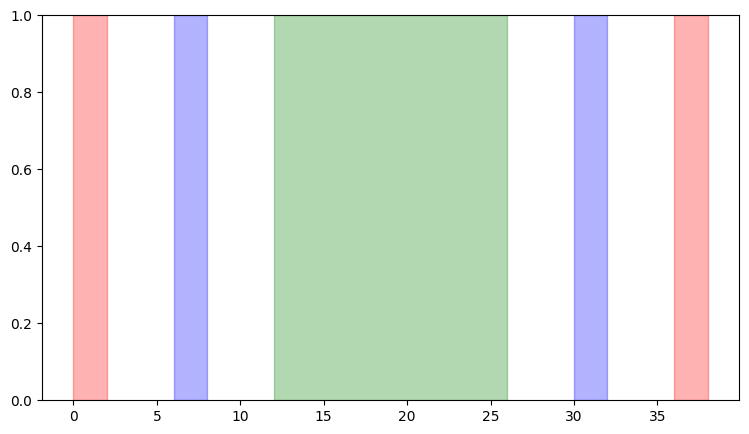

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
trace_geo(ax)
z_axis = data.axe_z

#Printing of the different composants of the potential
plt.plot(z_axis, -Phi0_maj, label=r'$\Phi_0 $ $[V]$', color='crimson')
plt.plot(z_axis, Phi1_maj, label=r'$\Phi_1$ $[V/mm^1]$', color='darkviolet')
plt.plot(z_axis, Phi2_maj, label=r'$\Phi_2$ $[V/mm^2]$', color='green')
plt.plot(z_axis, Phi3_maj, label=r'$\Phi_3$ $[V/mm^3]$', color='gold')
plt.plot(z_axis, 10*Phi4_maj, label=r'$\Phi_4 *100$ $[V/mm^4]$', color='royalblue')
plt.xlabel("z (mm)")
plt.ylabel("Potentiel")
plt.title("Décomposition multipolaire sur l’axe")
plt.grid()
plt.legend()
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)
plt.tight_layout()
plt.show()

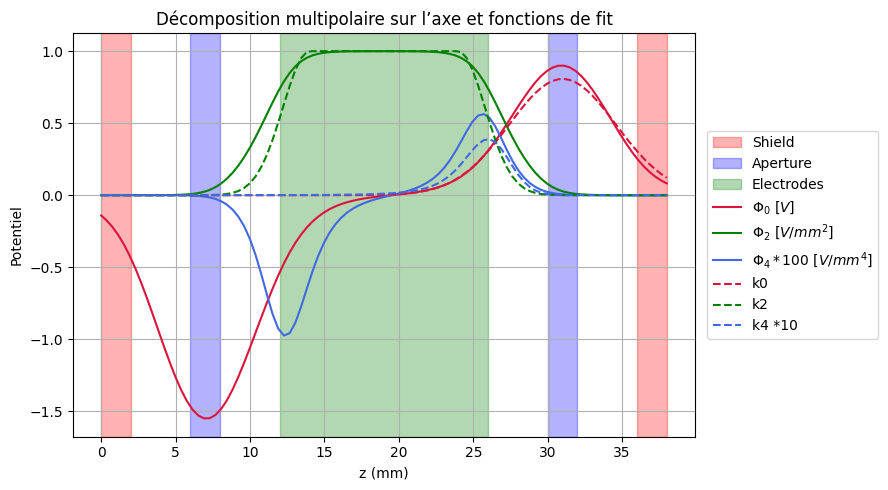

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
trace_geo(ax)

#Printing of the different composants of the potential
plt.plot(z_axis, Phi0_fit, label=r'$\Phi_0 $ $[V]$', color='crimson')
plt.plot(z_axis, Phi2_fit, label=r'$\Phi_2$ $[V/mm^2]$', color='green')
plt.plot(z_axis, 10*Phi4_fit, label=r'$\Phi_4 *10$ $[V/mm^4]$', color='royalblue')
plt.plot(z_axis, k0, label=r'k0', color='crimson', linestyle='dashed')
#plt.plot(z_axis, k0_2, color='crimson', linestyle='dashed')
plt.plot(z_axis, k2, label=r'k2', color='green', linestyle='dashed')
plt.plot(z_axis, 10*k4, label=r'k4 *10', color='royalblue', linestyle='dashed')
#plt.plot(z_axis, k4_2, color='royalblue', linestyle='dashed')
plt.xlabel("z (mm)")
plt.ylabel("Potentiel")
plt.title("Décomposition multipolaire sur l’axe et fonctions de fit")
plt.grid()
plt.legend()
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)
plt.tight_layout()
plt.show()

In [21]:
#constante
e = 1.6e-19 #C  charge élémentaire 
c = 3e8 #c en m/s


# Implémentation de la fonction RK4 utilisé pour résoudre les equa diffs
def RK4_step(f, y, t, h, alpha, beta):
    f1 = f(y, t, alpha, beta)
    f2 = f(y + h*f1/2, t + h/2, alpha, beta)
    f3 = f(y + h*f2/2, t + h/2, alpha, beta)
    f4 = f(y + h*f3, t + h, alpha, beta)
    
    y_next = y + (h/6)*(f1 + 2*f2 + 2*f3 + f4)
    return y_next

In [22]:
class ion:
    def __init__(self, mass,charge,name, x , vx,y,vy):
        #pour la solution analytique 
        self.mass = mass
        self.charge=charge
        self.name=name

        self.state_x = np.array([x, vx]) #position et  vitesse de la particule
        self.history_x = []# tableau qui enregiste les positions en cours du temps (utilisé avec self_step) pour pouvoir tracer 

        self.state_y = np.array([y, vy]) #position et  vitesse de la particule
        self.history_y = []# tableau qui enregiste les positions en cours du temps (utilisé avec self_step) pour pouvoir tracer 

    def afficher_detail(self):
        print(f"ion: {self.mass}, charge : {self.charge}, nom : {self.name}")

    def save_step(self): 
        self.history_x.append(self.state_x[0]) #sauvegarde la position ,
        self.history_y.append(self.state_y[0])

#simule la trajectoire d'un ion dans notre quadrupole
class simulateur :

    def equation(self, y, t, alpha, beta):
        u = y[0] # position inital 
        v = y[1] # pente
        du = v
        dv = -alpha * u - beta * v
        return np.array([du, dv])

    

    def simulation3(self, ion, data, Phi2_maj, potentials):
       
        V_acc = potentials.pot_acceleration  #  Potentiel accéleration Volts
        
        dz_mm = data.axe_z[1] - data.axe_z[0] # pas d'intégraiton 
        ion.save_step()
        
        for i in range(len(data.axe_z) - 1):
            # --- 2. Calcul du potentiel effectif ---
            # potentiel total 
            phi_total = V_acc + data.phi0[i]
            
            #pour pas que ca explose 
            if abs(phi_total) < 0.1:
                phi_total = 0.1 if phi_total >= 0 else -0.1

            # calcul terme equa dif 
            terme_axial = data.D2zphi0[i] / (4 * phi_total)
            terme_quad = Phi2_maj[i] / phi_total
            
            alphax = terme_axial - terme_quad # terme focalisant 
            alphay = terme_axial + terme_quad #terme défocalisatant 
            beta = data.D1zphi0[i] / (2 * phi_total)
            
            # utilisation RK4
            ion.state_x = RK4_step(self.equation, ion.state_x, data.axe_z[i], dz_mm, alphax, beta)
            ion.state_y = RK4_step(self.equation, ion.state_y, data.axe_z[i], dz_mm, alphay, beta)
            
            ion.save_step()
            
            
        
        
        
        

20000


'\n#---  Selon y ---\naxs[1, 1].plot(quad1.axe_z[:-1], ym, label="Rayon Marginal")\naxs[1, 1].plot(quad1.axe_z[:-1], yp, label="Rayon Principal")\naxs[1, 1].set_title("Simulation théorique  selon y ")\naxs[1, 1].set_xlabel("Z(mm)")\naxs[1,1].set_ylabel("y (mm)")\naxs[1, 1].axhline(0, color=\'black\', linestyle=\'--\', alpha=0.3)\naxs[1, 1].legend()\n\n'

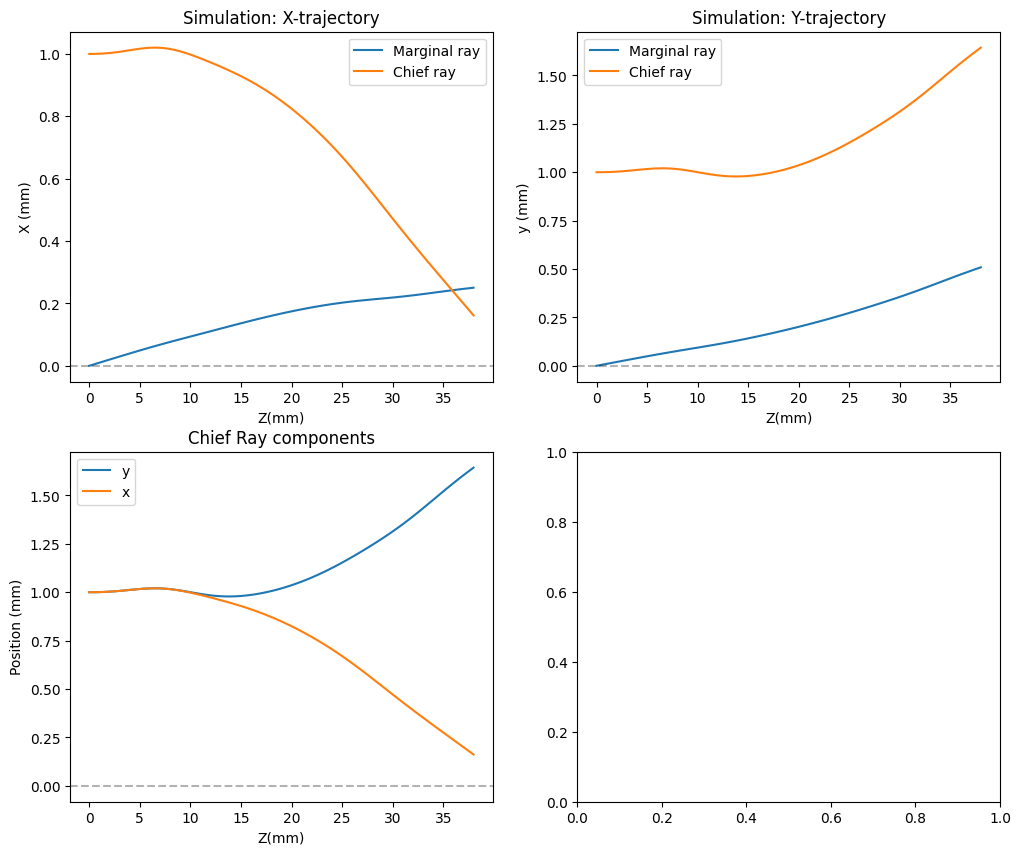

In [23]:
#initialisaation 
#entré (masse, charge, name, x,vx,y,vyà)
marginal = ion(1.6e-27, e, "proton", 0,0.01, 0, 0.01)
principal = ion(1.6e-27, e, "proton", 1, 0, 1, 0)

Ion = ion(1.6e-27,e,"proton",0,0,0,0)

# 1. Initialisation de la simulation
mon_moteur = simulateur() 

# 2. on applique pour chaque rayon
#mon_moteur.simulation(marginal, data)
#mon_moteur.simulation(principal, data)

mon_moteur.simulation3(marginal, data,Phi2_maj, potentials)
mon_moteur.simulation3(principal, data, Phi2_maj, potentials)

print(potentials.pot_acceleration)

'''

def solution_analytique(ion,potentiel,quad1, z0): #champ quadrupolaire  uniquement 
        
        xp = np.zeros(len(potentiel.axe_z)-1)
        xm = np.zeros(len(potentiel.axe_z)-1)
        yp = np.zeros(len(potentiel.axe_z)-1)
        ym = np.zeros(len(potentiel.axe_z)-1)

        for i in range(len(potentiel.axe_z)-1):
            z = potentiel.axe_z[i]
            w0 = np.sqrt(2*ion.charge*potentiel.VQ/ion.masse*(data.ro)**2)
            xp[i] = np.cos(w0*(z-z0))
            xm[i] = (1/w0)*np.sin(w0*(z-z0))
            yp[i] = np.cosh(w0*(z-z0))
            ym[i] = (1/w0)*np.sinh(w0*(z-z0))
        return xp,xm, ym, yp



#xp,xm, ym, yp = solution_analytique(Ion,data, 0)  

'''
fig, axs = plt.subplots(2, 2, figsize=(12, 10))


# ---  Selon x ---
axs[0, 0].plot(data.axe_z, marginal.history_x, label="Marginal ray")
axs[0, 0].plot(data.axe_z, principal.history_x, label="Chief ray")
axs[0, 0].set_title("Simulation: X-trajectory")
axs[0, 0].set_xlabel("Z(mm)")
axs[0, 0].set_ylabel("X (mm)")
axs[0, 0].axhline(0, color='black', linestyle='--', alpha=0.3)
axs[0, 0].legend()

#---  Selon y ---
axs[0, 1].plot(data.axe_z, marginal.history_y, label="Marginal ray")
axs[0, 1].plot(data.axe_z, principal.history_y, label="Chief ray")
axs[0, 1].set_title("Simulation: Y-trajectory")
axs[0, 1].set_xlabel("Z(mm)")
axs[0,1].set_ylabel("y (mm)")
axs[0, 1].axhline(0, color='black', linestyle='--', alpha=0.3)
axs[0, 1].legend()



#---    ---
axs[1, 0].plot(data.axe_z, principal.history_y, label="y")
axs[1, 0].plot(data.axe_z, principal.history_x, label="x")
axs[1, 0].set_title("Chief Ray components")
axs[1, 0].set_xlabel("Z(mm)")
axs[1, 0].set_ylabel("Position (mm)")
axs[1, 0].axhline(0, color='black', linestyle='--', alpha=0.3)
axs[1, 0].legend()

'''
#---  Selon y ---
axs[1, 1].plot(quad1.axe_z[:-1], ym, label="Rayon Marginal")
axs[1, 1].plot(quad1.axe_z[:-1], yp, label="Rayon Principal")
axs[1, 1].set_title("Simulation théorique  selon y ")
axs[1, 1].set_xlabel("Z(mm)")
axs[1,1].set_ylabel("y (mm)")
axs[1, 1].axhline(0, color='black', linestyle='--', alpha=0.3)
axs[1, 1].legend()

'''
